# Section 0: Import Library

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# Section 1: Data Load & Cleaning

In [23]:
# data_2021 = pd.read_csv("./Dataset/verify_BC_datasets/2021/PM25_with_geo_2021.csv")
data_2022 = pd.read_csv("./Dataset/verify_BC_datasets/2022/PM25_with_geo_2022.csv")
data_2023 = pd.read_csv("./Dataset/verify_BC_datasets/2023/PM25_with_geo_2023.csv")
data_2024 = pd.read_csv("./Dataset/verify_BC_datasets/2024/PM25_with_geo_2024.csv")
data_2025 = pd.read_csv("./Dataset/verify_BC_datasets/2025/PM25_with_geo_2025.csv")

all_raw_dataframes = [data_2022, data_2023, data_2024, data_2025]

From the results below, I noticed that 2025 has much less data than the other years. We need further investigation. We also need to convert the data types into the correct datetime format.

In [24]:
# Check the datatype shape & info
for i, df in enumerate(all_raw_dataframes, start=2022):
    print(f"Year {i}: DataFrame shape: {df.shape}")
    print()
    print(df.info())

Year 2022: DataFrame shape: (1191360, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191360 entries, 0 to 1191359
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Datetime   1191360 non-null  object 
 1   Station    1191360 non-null  object 
 2   PM25       1105225 non-null  float64
 3   Latitude   1191360 non-null  float64
 4   Longitude  1191360 non-null  float64
dtypes: float64(3), object(2)
memory usage: 45.4+ MB
None
Year 2023: DataFrame shape: (1165080, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165080 entries, 0 to 1165079
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Datetime   1165080 non-null  object 
 1   Station    1165080 non-null  object 
 2   PM25       1029679 non-null  float64
 3   Latitude   1165080 non-null  float64
 4   Longitude  1165080 non-null  float64
dtypes: float64(3), object(2)
memory usage: 44

In [25]:
# Turn Datetime column into datetime type
for df in all_raw_dataframes:
    df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
    df["Station"] = df["Station"].astype(str)
    
    # print after conversion to check if it worked
    print(f"Year {df['Datetime'].dt.year.iloc[0]}:\n{df.dtypes}\n")

Year 2022:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object

Year 2023:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object

Year 2024:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object

Year 2025:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object



Here is the corrected and more natural version:

Check for duplicates in each year where the same date and the same station have different values. We keep the older record to ensure the data remains consistent. This logic makes sense if we consider the possibility that someone updated a value but forgot to remove the previous entry.

After removing duplicates, the results make more sense for 2022, 2023, and 2025, as they now have consistent values. However, 2024 still differs, which could be due to the leap year. As for 2021, the discrepancy might be because some stations do not have sufficient data. We need to identify those stations.

In [26]:
# Check the duplicate for each year
for i, df in enumerate(all_raw_dataframes, start=2022):
    duplicate_count = df.drop_duplicates(subset=['Datetime', 'Station'], keep="last").shape[0]
    print(f"Year {i}: Number of duplicate rows: {duplicate_count}")
    
        
    # remove duplicates
    df.drop_duplicates(subset=['Datetime', 'Station'], keep="last", inplace=True)
        
    # After removing duplicates, check how many rows are left.
    print(f"Year {i}: Number of rows after removing duplicates: {df.drop_duplicates().shape[0]}\n")



Year 2022: Number of duplicate rows: 551880
Year 2022: Number of rows after removing duplicates: 551880

Year 2023: Number of duplicate rows: 551880
Year 2023: Number of rows after removing duplicates: 551880

Year 2024: Number of duplicate rows: 553392
Year 2024: Number of rows after removing duplicates: 553392

Year 2025: Number of duplicate rows: 551880
Year 2025: Number of rows after removing duplicates: 551880



There are four stations—**Langdale Elementary**, **Quesnel Johnston Avenue**, **Sparwood Centennial Square**, and **Elkford Rocky Mountain Elementary School**—with late-starting data. We can remove them because they are from different regions in British Columbia, so dropping them should not significantly reduce coverage within any single region.


In [27]:
# # Find the earliest record time ("start date") for each station in 2021
# dataframe_2021 = all_raw_dataframes[0]  # DataFrame for year 2021
# station_start_dates = dataframe_2021.groupby("Station")["Datetime"].min().sort_values()

# print("--- 2021 Station Start Dates (Late Bloomers) ---")
# late_stations = station_start_dates[station_start_dates > pd.Timestamp("2021-01-02")]
# print(late_stations)
# print(f"{late_stations.index.tolist()}")


In [28]:
# # Remove all the data that came from those late-starting stations in all years
# late_station_names = late_stations.index.tolist()
# for df in all_raw_dataframes:
#     df.drop(df[df["Station"].isin(late_station_names)].index, inplace=True)

In [29]:
for i, df in enumerate(all_raw_dataframes, start=2022):
    print(f"\nYEAR: {i}")
    print(f"Records: {len(df)}")
    if not df.empty:
        print(f"Time Range: {df['Datetime'].min()} to {df['Datetime'].max()}")
        print(f"Missing Values Percentage: {df.isna().sum().sum() / df.size * 100:.2f}%")
        
        # print total unique stations after removing late bloomers
        print(f"Total Unique Stations: {df['Station'].nunique()}")



YEAR: 2022
Records: 551880
Time Range: 2022-01-01 01:00:00 to 2023-01-01 00:00:00
Missing Values Percentage: 1.21%
Total Unique Stations: 63

YEAR: 2023
Records: 551880
Time Range: 2023-01-01 01:00:00 to 2024-01-01 00:00:00
Missing Values Percentage: 1.82%
Total Unique Stations: 63

YEAR: 2024
Records: 553392
Time Range: 2024-01-01 01:00:00 to 2025-01-01 00:00:00
Missing Values Percentage: 0.68%
Total Unique Stations: 63

YEAR: 2025
Records: 551880
Time Range: 2025-01-01 01:00:00 to 2026-01-01 00:00:00
Missing Values Percentage: 1.33%
Total Unique Stations: 63


We would like to investigate the missing values. In this case, the total number of missing values could be misleading. If a station has significantly more missing data than other stations, it may need to be dropped.

In [30]:
# %% Check missing values by station
print("--- Missing PM2.5 Percentage by Station (> 0%) ---")

for i, df in enumerate(all_raw_dataframes, start=2022):
    
    # print year
    print(f"\nYEAR: {i}\n")
    
    # 1. Group by 'Station' and calculate the percentage of NaN values in 'PM25'
    # We use .isna().mean() * 100 to get the percentage
    missing_stats = df.groupby('Station')['PM25'].apply(lambda x: x.isna().mean() * 100)
    
    # 2. Filter: Keep only stations with > 0% missing data
    missing_stats = missing_stats[missing_stats > 0]
    
    # 3. Sort: From Big to Small (Descending)
    missing_stats = missing_stats.sort_values(ascending=False)
    
    # 4. Print the result
    if not missing_stats.empty:
        # Print with 2 decimal places and a % sign
        print(missing_stats.apply(lambda x: f"{x:.2f}%"))
    else:
        print("✅ No stations have missing PM2.5 values (NaNs) in the recorded rows.")
        
    print("\n" + "-"*50)

--- Missing PM2.5 Percentage by Station (> 0%) ---

YEAR: 2022

Station
Valemount                           68.49%
Victoria Topaz                      62.32%
Courtenay Elementary School         57.41%
Prince George Plaza 400             30.19%
Sparwood Centennial Square          14.16%
                                     ...  
Fort St John Key Learning Centre     0.41%
Vernon Science Centre                0.31%
Kamloops Federal Building            0.27%
Smithers Muheim Memorial             0.21%
Kelowna KLO Road                     0.16%
Name: PM25, Length: 63, dtype: object

--------------------------------------------------

YEAR: 2023

Station
Houston Firehall                87.00%
Victoria Topaz                  57.88%
Duncan College Street           55.32%
Colwood City Hall               51.99%
Valemount                       35.24%
                                 ...  
Abbotsford Central               0.64%
Tsawwassen                       0.42%
Abbotsford A Columbia Street    

Based on the results above, some stations have more than 20% missing data. In general, when more than 20% of a dataset is missing, it becomes difficult to impute reliably. Therefore, we will remove these stations for all years to ensure data consistency.

In [31]:
# %% Remove stations with > 20% missing data
print("--- Removing Stations with > 20% Missing Data ---")

# 1. Identify stations to remove
stations_to_remove = set()


for i, df in enumerate(all_raw_dataframes, start=2022):
    # Calculate missing percentage per station
    missing_series = df.groupby('Station')['PM25'].apply(lambda x: x.isna().mean())
    
    # Identify stations with > 20% missing
    bad_stations = missing_series[missing_series > 0.20].index.tolist()
    
    if bad_stations:
        print(f"Year {i}: Found {len(bad_stations)} stations with > 20% missing data.")
        stations_to_remove.update(bad_stations)

# 2. Print summary of stations to be removed
print(f"\n🚫 Total Unique Stations to Remove: {len(stations_to_remove)}")
print(f"Stations: {sorted(list(stations_to_remove))}")

# 3. Remove them from all datasets
if stations_to_remove:
    for i, df in enumerate(all_raw_dataframes, start=2022):
        original_count = len(df)
        original_count = len(df)
        
        # Filter out the bad stations
        # We use ~ (tilde) to negate the condition (Keep stations NOT in the remove list)
        all_raw_dataframes[i - 2022] = df[~df['Station'].isin(stations_to_remove)]
        
        dropped_count = original_count - len(all_raw_dataframes[i - 2022])
        print(f"✅ Year {i}: Dropped {dropped_count} rows (removed {len(stations_to_remove)} stations).")

# 4. Final check of remaining stations
if all_raw_dataframes:
    first_year = 2022
    remaining_stations = all_raw_dataframes[0]["Station"].nunique()
    print(f"\n🎉 Final Common Station Count: {remaining_stations}")

--- Removing Stations with > 20% Missing Data ---
Year 2022: Found 4 stations with > 20% missing data.
Year 2023: Found 7 stations with > 20% missing data.
Year 2024: Found 2 stations with > 20% missing data.
Year 2025: Found 3 stations with > 20% missing data.

🚫 Total Unique Stations to Remove: 13
Stations: ['Colwood City Hall', 'Courtenay Elementary School', 'Crofton Elementary', 'Duncan College Street', 'Duncan Deykin Avenue', 'Houston Firehall', 'Nanaimo Labieux Road', 'North Vancouver Second Narrows', 'Prince George Plaza 400', 'Quesnel Johnston Avenue', 'Terrace Skeena Middle School', 'Valemount', 'Victoria Topaz']
✅ Year 2022: Dropped 113880 rows (removed 13 stations).
✅ Year 2023: Dropped 113880 rows (removed 13 stations).
✅ Year 2024: Dropped 114192 rows (removed 13 stations).
✅ Year 2025: Dropped 113880 rows (removed 13 stations).

🎉 Final Common Station Count: 50


In [32]:
# %% Check missing values by station
print("--- Missing PM2.5 Percentage by Station (> 0%) ---")

for i, df in enumerate(all_raw_dataframes, start=2022):
    
    # print year
    print(f"\nYEAR: {i}\n")
    
    # 1. Group by 'Station' and calculate the percentage of NaN values in 'PM25'
    # We use .isna().mean() * 100 to get the percentage
    missing_stats = df.groupby('Station')['PM25'].apply(lambda x: x.isna().mean() * 100)
    
    # 2. Filter: Keep only stations with > 0% missing data
    missing_stats = missing_stats[missing_stats > 0]
    
    # 3. Sort: From Big to Small (Descending)
    missing_stats = missing_stats.sort_values(ascending=False)
    
    # 4. Print the result
    if not missing_stats.empty:
        # Print with 2 decimal places and a % sign
        print(missing_stats.apply(lambda x: f"{x:.2f}%"))
    else:
        print("✅ No stations have missing PM2.5 values (NaNs) in the recorded rows.")
        
    print("\n" + "-"*50)

--- Missing PM2.5 Percentage by Station (> 0%) ---

YEAR: 2022

Station
Sparwood Centennial Square                  14.16%
Elk Falls Dogwood                           12.58%
Whistler Meadow Park                        11.22%
Prince Rupert Fairview                       8.52%
Mission School Works Yard                    8.03%
Vanderhoof Courthouse                        6.16%
Kitimat Haul Road                            5.14%
Kitimat Haisla Village                       4.67%
Kitimat Whitesail                            3.92%
Fort St John North Camp C                    3.69%
Crofton Substation                           3.55%
Elkford Rocky Mountain Elementary School     3.53%
Harmac Cedar Woobank                         3.28%
Kitimat Riverlodge                           3.13%
Pitt Meadows Meadowlands School              3.06%
Hope Airport                                 2.76%
Surrey East                                  2.56%
Peace Valley Attachie Flat Upper Terrace     2.56%
Fort St Jo

## 1. Define Distance Metric

We first define the **Haversine Formula**, which calculates the precise "Great Circle" distance between two points on the Earth's surface. This is critical for accurate spatial weighting in high-latitude regions like BC.


In [33]:
def haversine_matrix(coords):
    """
    Calculates the Great Circle distance between multiple points on Earth.
    
    Args:
        coords: Numpy array of shape (N, 2) containing [[Lat, Lon], ...] in decimal degrees.
    
    Returns:
        N x N matrix of distances in Kilometers.
    """
    R = 6371.0  # Earth radius in kilometers
    
    # Convert degrees to radians
    rads = np.radians(coords)
    lat = rads[:, 0][:, np.newaxis]
    lon = rads[:, 1][:, np.newaxis]
    
    # Vectorized Haversine formula
    dlat = lat - lat.T
    dlon = lon - lon.T
    a = np.sin(dlat / 2)**2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


## 2. Define the Imputation Function

This is the core engine of the pipeline. It takes a single year's dataframe and applies the three-step imputation logic sequentially.


In [34]:
def rigorous_imputation_pipeline(df, year_label):
    """
    Executes the 3-stage imputation pipeline:
    1. Temporal Forward Fill (Limit=1hr) -> Fixes micro-gaps.
    2. Spatial IDW (Haversine) -> Fixes macro-gaps using neighbors.
    3. Linear Interpolation -> Final cleanup for network-wide outages.
    """
    df = df.copy()
    
    # Ensure Datetime is properly formatted and sorted
    df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
    df = df.sort_values(['Station', 'Datetime'])
    
    initial_missing = df['PM25'].isna().sum()
    if initial_missing == 0:
        print(f"[{year_label}] ✅ Data is already complete.")
        return df

    # --- Step 1: Temporal Forward Fill (Limit 1 hour) ---
    # We only fill gaps of 1 hour to preserve data integrity (no future data used).
    df['PM25'] = df.groupby('Station')['PM25'].ffill(limit=1)
    missing_s1 = df['PM25'].isna().sum()
    
    # --- Step 2: Spatial IDW (Haversine Distance) ---
    if missing_s1 > 0:
        # Pivot to wide format: Index=Time, Columns=Stations
        pivot = df.pivot_table(index='Datetime', columns='Station', values='PM25')
        
        # Prepare coordinates aligned with pivot columns
        stations_info = df[['Station', 'Latitude', 'Longitude']].drop_duplicates('Station').set_index('Station')
        stations_info = stations_info.loc[pivot.columns]
        coords = stations_info[['Latitude', 'Longitude']].values
        
        # Calculate Distance Matrix
        dists = haversine_matrix(coords)
        np.fill_diagonal(dists, np.inf) # Ignore self-distance
        
        # Calculate Weights (Inverse Distance Squared)
        weights = 1.0 / (dists + 1e-6)**2 
        
        # Vectorized Imputation
        values = pivot.values
        # Mask: 1 where data exists, 0 where NaN
        mask_present = (~np.isnan(values)).astype(float)
        values_zeroed = np.nan_to_num(values)
        
        # Weighted Average Calculation
        with np.errstate(divide='ignore', invalid='ignore'):
            numerator = values_zeroed @ weights.T
            denominator = mask_present @ weights.T
            imputed = numerator / denominator
        
        # Fill missing values in the pivot table
        pivot_filled = pivot.copy()
        mask_missing = pivot.isna()
        pivot_filled[mask_missing] = pd.DataFrame(imputed, index=pivot.index, columns=pivot.columns)[mask_missing]
        
        # Convert back to long format (melt) and merge
        df_filled = pivot_filled.reset_index().melt(id_vars='Datetime', var_name='Station', value_name='PM25_Filled')
        df = pd.merge(df, df_filled, on=['Datetime', 'Station'], how='left')
        
        # Apply the filled values
        df['PM25'] = df['PM25'].fillna(df['PM25_Filled'])
        df = df.drop(columns=['PM25_Filled'])
    
    missing_s2 = df['PM25'].isna().sum()

    # --- Step 3: Final Cleanup (Linear Interpolation) ---
    # Handles rare cases where ALL stations are down simultaneously (IDW fails).
    if missing_s2 > 0:
        df['PM25'] = df.groupby('Station')['PM25'].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )
    
    missing_final = df['PM25'].isna().sum()
    
    # Print Summary Stats
    print(f"[{year_label}] Imputation Stats:")
    print(f"   - Initial Missing: {initial_missing}")
    print(f"   - Recovered by S1 (Time):  {initial_missing - missing_s1}")
    print(f"   - Recovered by S2 (Space): {missing_s1 - missing_s2}")
    print(f"   - Recovered by S3 (Clean): {missing_s2 - missing_final}")
    print(f"   - Final Missing: {missing_final}")
    
    return df


## 3. Main Execution: Process 2022-2025

Here we iterate through the datasets. We first enforce spatial consistency by keeping only stations that exist in all four years (Common Stations).


In [35]:
# Configuration
years = [2022, 2023, 2024, 2025]
# Assuming 'all_raw_dataframes' is already loaded: [data_2022, data_2023, data_2024, data_2025]
cleaned_dfs = []

print("--- 1. Filtering for Common Stations ---")

# Identify stations present in ALL years
common_stations = set(all_raw_dataframes[0]['Station'].unique())
for df in all_raw_dataframes[1:]:
    common_stations &= set(df['Station'].unique())

print(f"Identified {len(common_stations)} common stations across 4 years.")

print("\n--- 2. Running Rigorous Imputation ---")

for i, df in enumerate(all_raw_dataframes):
    year = years[i]
    
    # Filter dataset to include only common stations
    df_target = df[df['Station'].isin(common_stations)].copy()
    
    # Run the imputation pipeline
    df_clean = rigorous_imputation_pipeline(df_target, str(year))
    cleaned_dfs.append(df_clean)

print("\nProcessing Complete.")


--- 1. Filtering for Common Stations ---
Identified 50 common stations across 4 years.

--- 2. Running Rigorous Imputation ---
[2022] Imputation Stats:
   - Initial Missing: 11655
   - Recovered by S1 (Time):  2402
   - Recovered by S2 (Space): 9253
   - Recovered by S3 (Clean): 0
   - Final Missing: 0
[2023] Imputation Stats:
   - Initial Missing: 17088
   - Recovered by S1 (Time):  2613
   - Recovered by S2 (Space): 14475
   - Recovered by S3 (Clean): 0
   - Final Missing: 0
[2024] Imputation Stats:
   - Initial Missing: 11854
   - Recovered by S1 (Time):  2273
   - Recovered by S2 (Space): 9581
   - Recovered by S3 (Clean): 0
   - Final Missing: 0
[2025] Imputation Stats:
   - Initial Missing: 15134
   - Recovered by S1 (Time):  2729
   - Recovered by S2 (Space): 12405
   - Recovered by S3 (Clean): 0
   - Final Missing: 0

Processing Complete.


## 4. Final Assembly and Validation

Finally, we combine all processed years into a single master dataset and verify that zero missing values remain.


In [36]:
# Combine all years into one DataFrame
full_imputed_data = pd.concat(cleaned_dfs, ignore_index=True).sort_values(['Datetime', 'Station'])

# Final Validation
print("--- Final Dataset Validation ---")
total_rows = len(full_imputed_data)
total_nans = full_imputed_data['PM25'].isna().sum()

print(f"Total Records: {total_rows}")
print(f"Time Range:    {full_imputed_data['Datetime'].min()} to {full_imputed_data['Datetime'].max()}")

if total_nans == 0:
    print("🎉 SUCCESS: The dataset is 100% complete with 0 missing values.")
else:
    print(f"⚠️ WARNING: There are still {total_nans} missing values. Please investigate.")

# Preview the clean data and sort by datetime and station for better readability
full_imputed_data.sort_values(['Datetime', 'Station'], inplace=True)

# Reset index for cleanliness
full_imputed_data.reset_index(drop=True, inplace=True)


full_imputed_data.head()

--- Final Dataset Validation ---
Total Records: 1753200
Time Range:    2022-01-01 01:00:00 to 2026-01-01 00:00:00
🎉 SUCCESS: The dataset is 100% complete with 0 missing values.


,Datetime,Station,PM25,Latitude,Longitude
0,2022-01-01 01:00:00,Abbotsford A Columbia Street,2.840752,49.021500,-122.326500
1,2022-01-01 01:00:00,Abbotsford Central,14.556050,49.042600,-122.309800
2,2022-01-01 01:00:00,Burnaby Kensington Park,11.800620,49.279200,-122.970700
3,2022-01-01 01:00:00,Burnaby South,3.421575,49.215200,-122.985700
4,2022-01-01 01:00:00,Burns Lake Fire Centre,3.517412,54.230731,-125.764354


In [37]:
import pandas as pd
import geopandas as gpd
import requests
import os

# ---------------------------------------------------------
# Pre-check: Ensure the source DataFrame exists
# ---------------------------------------------------------
if 'full_imputed_data' not in locals():
    raise ValueError("Variable 'full_imputed_data' is missing. Please ensure the data is loaded first.")

# Create a unique list of stations to speed up spatial operations
# (Processing unique points is much faster than processing millions of rows)
unique_stations_dataframe = full_imputed_data[['Station', 'Latitude', 'Longitude']].drop_duplicates().reset_index(drop=True)

# ---------------------------------------------------------
# 1. Download BC Air Zones GeoJSON (Official Source)
# ---------------------------------------------------------
geojson_url = "https://catalogue.data.gov.bc.ca/dataset/e8eeefc4-2826-47bc-8430-85703d328516/resource/c495d082-b586-4df0-9e06-bd6b66a8acd9/download/bcairzones.geojson"
local_geojson_filename = "bcairzones.geojson"

if not os.path.exists(local_geojson_filename):
    print("Downloading BC Air Zones GeoJSON file...")
    try:
        response = requests.get(geojson_url)
        with open(local_geojson_filename, 'wb') as file_handle:
            file_handle.write(response.content)
        print("Download successful.")
    except Exception as e:
        print(f"Error downloading file: {e}")

# ---------------------------------------------------------
# 2. Load Map and Perform Spatial Projection
# ---------------------------------------------------------
try:
    # Load the GeoJSON file into a GeoDataFrame
    gdf_bc_air_zones = gpd.read_file(local_geojson_filename)
    
    # Ensure the Coordinate Reference System (CRS) is set to WGS84 (Lat/Lon) if missing
    if gdf_bc_air_zones.crs is None:
        gdf_bc_air_zones.set_crs(epsg=4326, inplace=True)
    
    # Project to EPSG:3005 (BC Albers) for accurate distance calculations
    # This is the standard projection for British Columbia government data
    gdf_bc_air_zones = gdf_bc_air_zones.to_crs(epsg=3005)

    # Convert station DataFrame to GeoDataFrame
    gdf_unique_stations = gpd.GeoDataFrame(
        unique_stations_dataframe,
        geometry=gpd.points_from_xy(unique_stations_dataframe.Longitude, unique_stations_dataframe.Latitude),
        crs="EPSG:4326"
    )
    
    # Project stations to EPSG:3005 to match the map projection
    gdf_unique_stations = gdf_unique_stations.to_crs(epsg=3005)

    # ---------------------------------------------------------
    # 3. Spatial Join using Nearest Neighbor
    # ---------------------------------------------------------
    # Use sjoin_nearest to find the closest air zone for each station.
    # This resolves issues where coastal stations might fall slightly outside polygon boundaries.
    joined_stations_with_zones = gpd.sjoin_nearest(
        gdf_unique_stations, 
        gdf_bc_air_zones, 
        how="left", 
        distance_col="distance_to_boundary"
    )

    # Identify the column containing the Air Zone name (usually 'Airzone' or 'Name')
    air_zone_column_name = [col for col in gdf_bc_air_zones.columns if 'zone' in col.lower() or 'name' in col.lower()][0]
    
    # Create a mapping DataFrame: Station -> Official Air Zone
    station_air_zone_mapping = joined_stations_with_zones[['Station', air_zone_column_name]].rename(columns={air_zone_column_name: 'Official_Air_Zone'})

    # ---------------------------------------------------------
    # 4. Merge Results back to Original Data
    # ---------------------------------------------------------
    full_imputed_data_with_air_zones = pd.merge(full_imputed_data, station_air_zone_mapping, on='Station', how='left')

    # ---------------------------------------------------------
    # 5. Simple Result Printout
    # ---------------------------------------------------------
    print("--- Processing Complete ---")
    print(f"Total records in dataset: {len(full_imputed_data_with_air_zones)}")
    
    # Check for any unclassified records (should be 0)
    missing_values_count = full_imputed_data_with_air_zones['Official_Air_Zone'].isna().sum()
    print(f"Unclassified records (NaN): {missing_values_count}")

    print("\n--- Air Zone Distribution ---")
    print(full_imputed_data_with_air_zones['Official_Air_Zone'].value_counts())

    print("\n--- Check Specific Coastal Stations ---")
    # Verifying specific stations that were previously problematic
    stations_to_verify = ['Kitimat Haul Road', 'Prince Rupert Fairview', 'Crofton Substation']
    verification_subset = full_imputed_data_with_air_zones[full_imputed_data_with_air_zones['Station'].isin(stations_to_verify)]
    
    if not verification_subset.empty:
        print(verification_subset[['Station', 'Official_Air_Zone']].drop_duplicates().to_string(index=False))
    else:
        print("Verification stations not found in the dataset.")

except Exception as e:
    print(f"An error occurred during processing: {e}")

--- Processing Complete ---
Total records in dataset: 2910312
Unclassified records (NaN): 0

--- Air Zone Distribution ---
Official_Air_Zone
Lower Fraser Valley    1472688
Central Interior        350640
Southern Interior       315576
Coastal                 315576
Northeast               245448
Georgia Strait          210384
Name: count, dtype: int64

--- Check Specific Coastal Stations ---
               Station   Official_Air_Zone
    Crofton Substation Lower Fraser Valley
    Crofton Substation      Georgia Strait
     Kitimat Haul Road             Coastal
     Kitimat Haul Road    Central Interior
Prince Rupert Fairview             Coastal


In [38]:
full_imputed_data_with_air_zones.to_csv("./Dataset/verify_BC_datasets/PM25_imputed_full_2022_2025.csv", index=False)

In [39]:
full_imputed_data_with_air_zones.head()

,Datetime,Station,PM25,Latitude,Longitude,Official_Air_Zone
0,2022-01-01 01:00:00,Abbotsford A Columbia Street,2.840752,49.0215,-122.3265,Lower Fraser Valley
1,2022-01-01 01:00:00,Abbotsford A Columbia Street,2.840752,49.0215,-122.3265,Lower Fraser Valley
2,2022-01-01 01:00:00,Abbotsford Central,14.556050,49.0426,-122.3098,Lower Fraser Valley
3,2022-01-01 01:00:00,Abbotsford Central,14.556050,49.0426,-122.3098,Lower Fraser Valley
4,2022-01-01 01:00:00,Burnaby Kensington Park,11.800620,49.2792,-122.9707,Lower Fraser Valley


# Section 2: EDA

## Section 2.1: 1 Dimension Variable

In this section, we focus on the one dimension variable only.

In the following part, we wonly focus on how the date, weekly, monthly will affect the PM2.5.

### Section 2.1.1: Data Preparation & Feature Engineering
Before plotting, we need to extract time-based features from your datetime column. This step creates the foundation for all subsequent charts by calculating hours, days of the week, and defining "Weekend" vs. "Weekday".

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# ---------------------------------------------------------
# 1. Setup & Feature Engineering
# ---------------------------------------------------------
# Create a working copy of your dataframe
df = full_imputed_data_with_air_zones.copy()

# Configuration: Update these if your column names differ
time_col = 'Datetime'  # The column containing date and time
val_col = 'PM25'       # The value column to visualize

# Ensure the time column is in datetime object format and sorted
df[time_col] = pd.to_datetime(df[time_col])
df.sort_values(by=time_col, inplace=True)

# Generate time-based features for grouping
df['hour'] = df[time_col].dt.hour
df['day_of_week'] = df[time_col].dt.day_name()
df['month'] = df[time_col].dt.month
df['year'] = df[time_col].dt.year

# Define "Day Type" to distinguish Weekends (Sat/Sun) from Weekdays
# .dayofweek: 0=Monday, 6=Sunday. We classify >= 5 as Weekend.
df['day_type'] = df[time_col].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Define a custom sort order for days so charts plot Mon->Sun instead of alphabetically
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

### Section 2.1.2: Micro-Analysis (Human Activity)
This section focuses on short-term patterns driven by human behavior.

- Chart 1 (Daily Rhythm): Highlights "Rush Hours" (7-9 AM and 4-7 PM) in red to show traffic impact.

- Chart 2 (Lifestyle): Compares the hourly curve of Weekdays vs. Weekends.

- Chart 3 (Weekly Trend): Shows how pollution accumulates throughout the work week.

In [ ]:
# ---------------------------------------------------------
# ACT 1: Micro-Analysis (Daily & Weekly Patterns)
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(3, 1, figsize=(14, 18), constrained_layout=True)

# --- Chart 1: Daily Cycle with Rush Hours ---
hourly_avg = df.groupby('hour')[val_col].mean().reset_index()

sns.lineplot(data=hourly_avg, x='hour', y=val_col, ax=axes1[0], 
             marker='o', color='#2d3436', linewidth=3, zorder=10)

# Highlight Rush Hours: Morning (7-9) and Evening (16-19)
axes1[0].axvspan(7, 9, color='#e74c3c', alpha=0.15, label='Rush Hour')
axes1[0].axvspan(16, 19, color='#e74c3c', alpha=0.15)
axes1[0].set_title('1. Daily Rhythm: Highlighting Rush Hours', fontsize=16, fontweight='bold', loc='left')
axes1[0].set_xticks(range(0, 24))
axes1[0].legend(['Avg Value', 'Rush Hours'], loc='upper left')

# --- Chart 2: Weekday vs. Weekend Comparison ---
split_avg = df.groupby(['hour', 'day_type'])[val_col].mean().reset_index()

sns.lineplot(data=split_avg, x='hour', y=val_col, hue='day_type', ax=axes1[1], 
             marker='o', palette={'Weekday': '#6c5ce7', 'Weekend': '#ff7675'}, linewidth=3)

axes1[1].set_title('2. Lifestyle Impact: Weekday vs. Weekend', fontsize=16, fontweight='bold', loc='left')
axes1[1].set_xticks(range(0, 24))

# --- Chart 3: Weekly Accumulation ---
# Reindex ensures the x-axis follows Monday -> Sunday order
weekly_avg = df.groupby('day_of_week')[val_col].mean().reindex(week_order).reset_index()

sns.lineplot(data=weekly_avg, x='day_of_week', y=val_col, ax=axes1[2], 
             marker='s', color='#0984e3', linewidth=3)

axes1[2].set_title('3. Weekly Accumulation Trend', fontsize=16, fontweight='bold', loc='left')
axes1[2].grid(True, axis='x')

plt.show()

3. Act 2: Macro-Analysis (Seasonal Trends)
This section zooms out to look at annual patterns.

- Chart 4: Aggregates all data to show the general shape of the year (Seasonality).

- Chart 5: Splits the data by year to show year-over-year volatility (e.g., Was 2023 worse than 2022?).

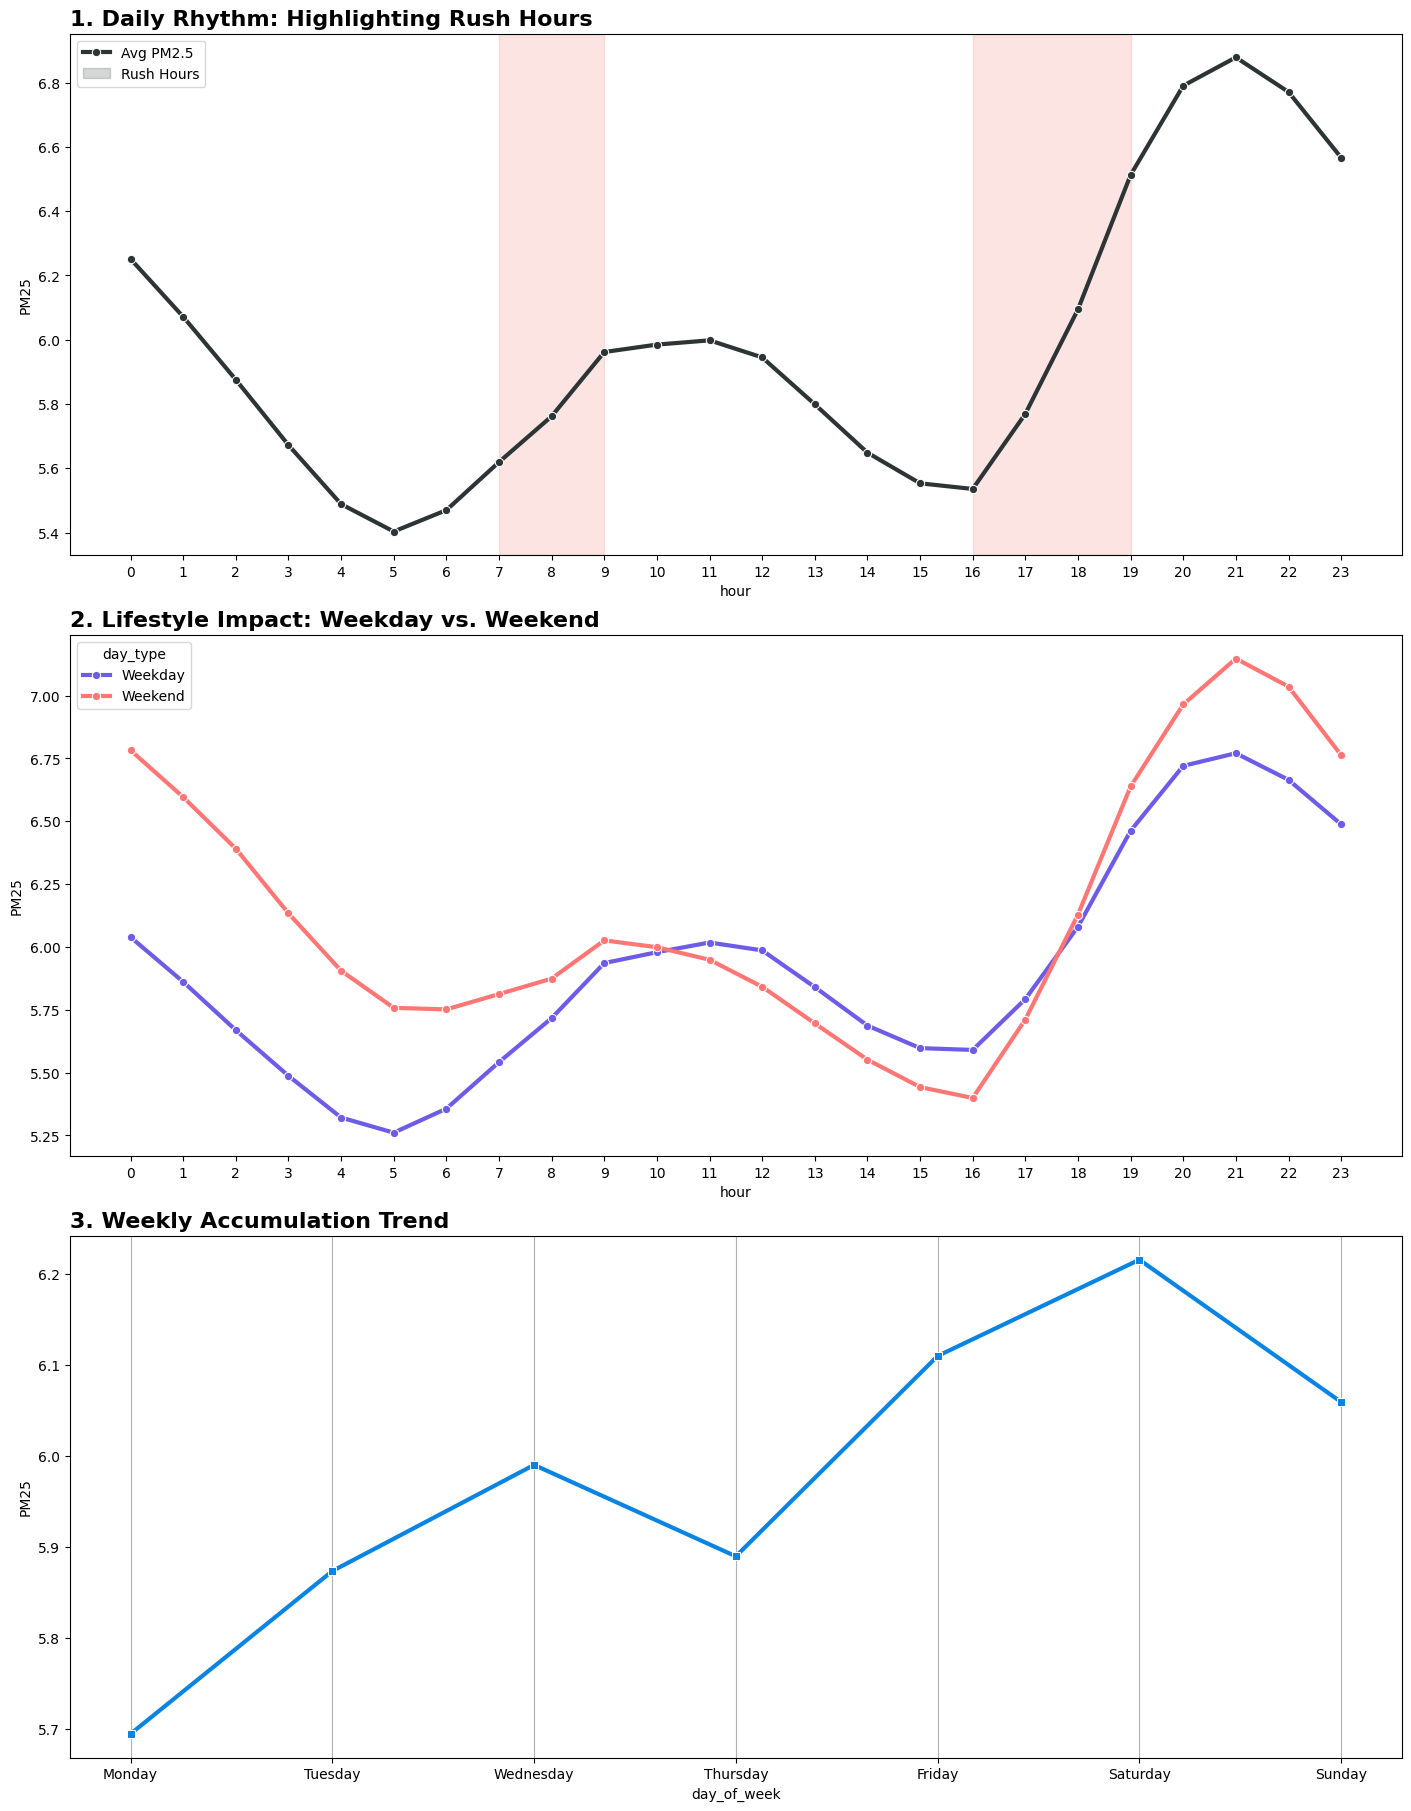

In [43]:
# 2. ACT 1: Micro-Analysis (Daily & Weekly Patterns)
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(3, 1, figsize=(14, 18), constrained_layout=True)

# --- Chart 1: Daily Cycle (Hourly Average) ---
hourly_avg = df.groupby('hour')[val_col].mean().reset_index()

sns.lineplot(data=hourly_avg, x='hour', y=val_col, ax=axes1[0], 
             marker='o', color='#2d3436', linewidth=3, zorder=10)

# Highlight Rush Hours (Morning: 7-9, Evening: 16-19)
axes1[0].axvspan(7, 9, color='#e74c3c', alpha=0.15, label='Rush Hour')
axes1[0].axvspan(16, 19, color='#e74c3c', alpha=0.15)
axes1[0].set_title('1. Daily Rhythm: Highlighting Rush Hours', fontsize=16, fontweight='bold', loc='left')
axes1[0].set_xticks(range(0, 24))
axes1[0].legend(['Avg PM2.5', 'Rush Hours'], loc='upper left')

# --- Chart 2: Weekday vs. Weekend ---
split_avg = df.groupby(['hour', 'day_type'])[val_col].mean().reset_index()

sns.lineplot(data=split_avg, x='hour', y=val_col, hue='day_type', ax=axes1[1], 
             marker='o', palette={'Weekday': '#6c5ce7', 'Weekend': '#ff7675'}, linewidth=3)

axes1[1].set_title('2. Lifestyle Impact: Weekday vs. Weekend', fontsize=16, fontweight='bold', loc='left')
axes1[1].set_xticks(range(0, 24))

# --- Chart 3: Weekly Trend ---
# Reindex to ensure Monday-Sunday order
weekly_avg = df.groupby('day_of_week')[val_col].mean().reindex(week_order).reset_index()

sns.lineplot(data=weekly_avg, x='day_of_week', y=val_col, ax=axes1[2], 
             marker='s', color='#0984e3', linewidth=3)

axes1[2].set_title('3. Weekly Accumulation Trend', fontsize=16, fontweight='bold', loc='left')
axes1[2].grid(True, axis='x')

plt.show()

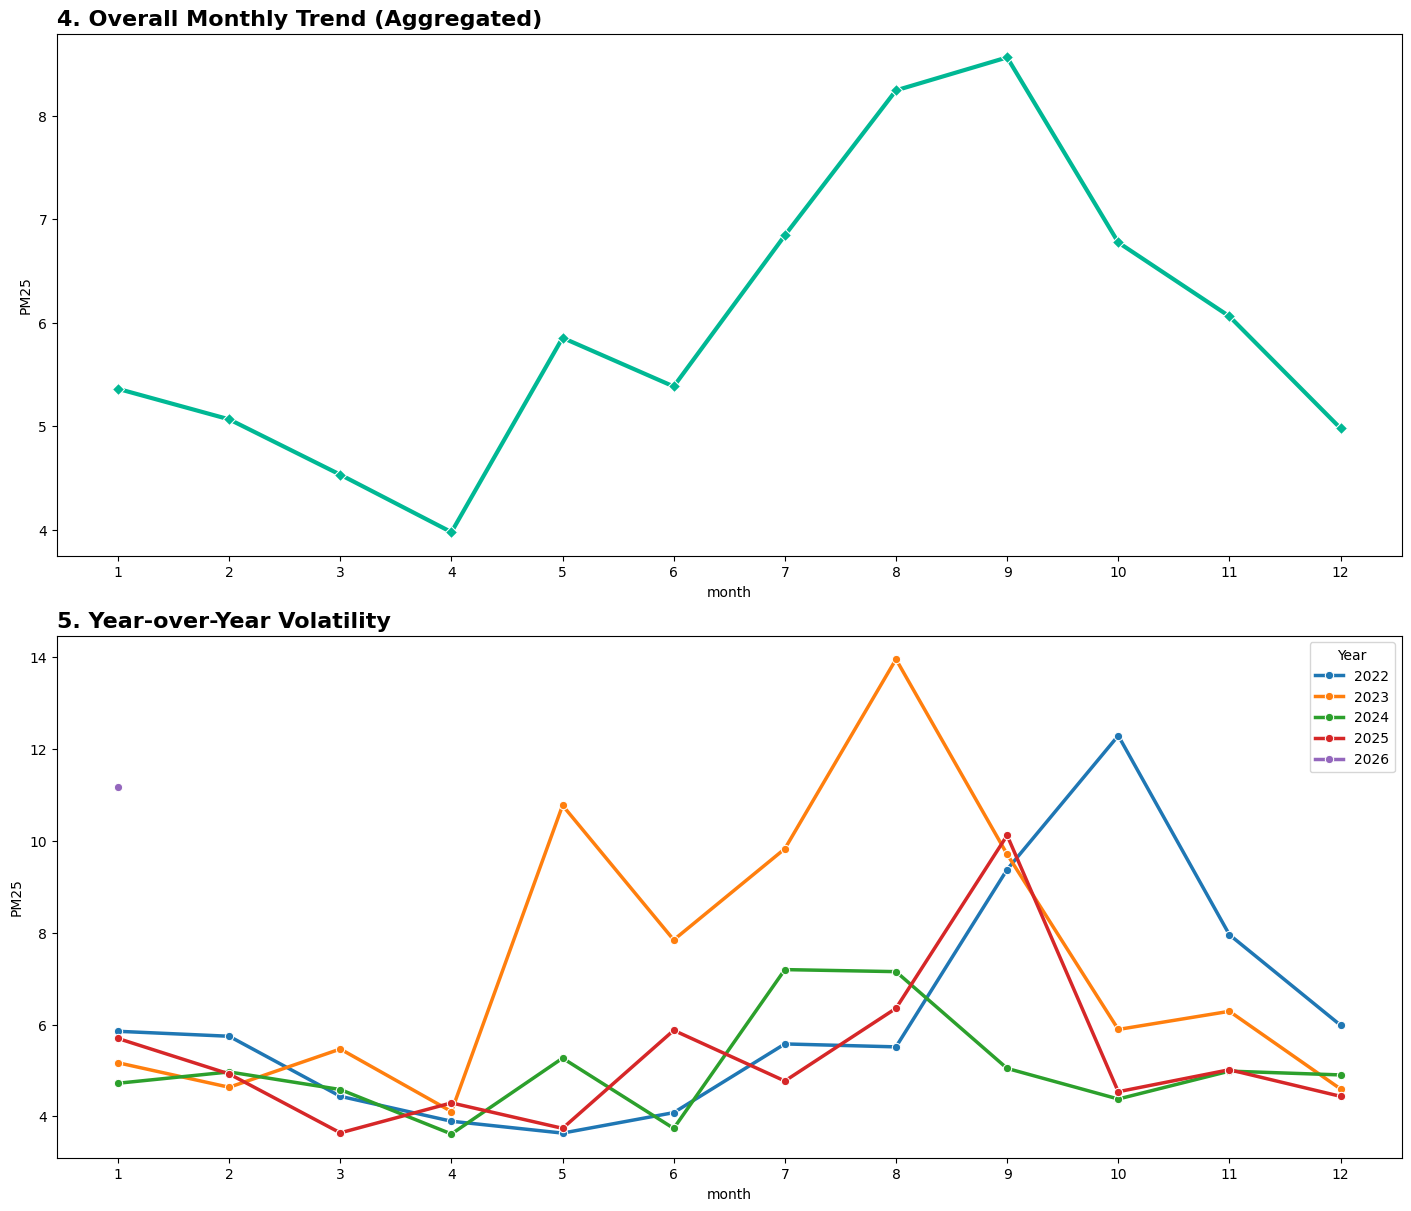

In [44]:
# 3. ACT 2: Macro-Analysis (Monthly & Yearly Patterns)
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(2, 1, figsize=(14, 12), constrained_layout=True)

# --- Chart 4: Overall Monthly Trend ---
monthly_avg = df.groupby('month')[val_col].mean().reset_index()

sns.lineplot(data=monthly_avg, x='month', y=val_col, ax=axes2[0], 
             marker='D', color='#00b894', linewidth=3)

axes2[0].set_title('4. Overall Monthly Trend (Aggregated)', fontsize=16, fontweight='bold', loc='left')
axes2[0].set_xticks(range(1, 13))

# --- Chart 5: Year-over-Year Volatility ---
monthly_yearly_avg = df.groupby(['year', 'month'])[val_col].mean().reset_index()

sns.lineplot(data=monthly_yearly_avg, x='month', y=val_col, hue='year', ax=axes2[1], 
             marker='o', palette='tab10', linewidth=2.5)

axes2[1].set_title('5. Year-over-Year Volatility', fontsize=16, fontweight='bold', loc='left')
axes2[1].set_xticks(range(1, 13))
axes2[1].legend(title='Year', loc='upper right')

plt.show()

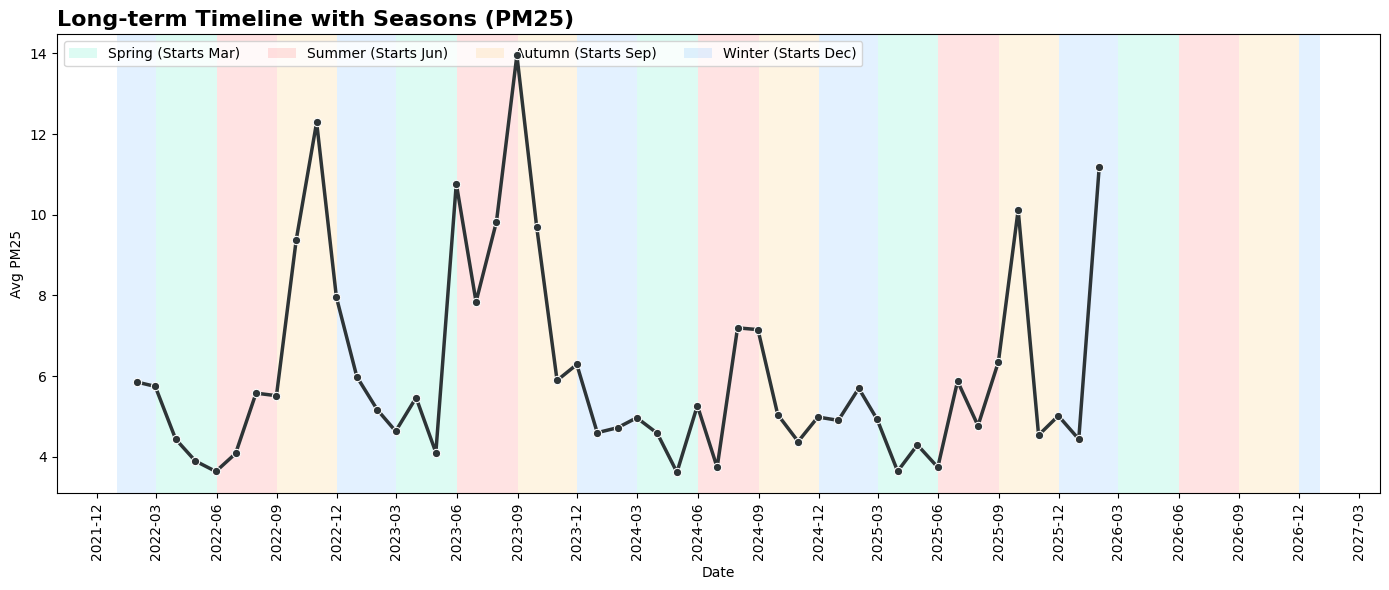

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. Prepare Data
# ---------------------------------------------------------
# Create a copy to avoid modifying the original dataframe
df_plot = full_imputed_data_with_air_zones.copy()

# Set your column names here (Update if yours are 'Date' or 'PM2.5')
time_col = 'Datetime' 
value_col = 'PM25'

# Ensure the time column is in datetime format
df_plot[time_col] = pd.to_datetime(df_plot[time_col])

# Group by Month End ('ME') to match the "Long-term Timeline" style in EDA_Andy
# If you prefer daily data, change freq='D'
long_term_trend = df_plot.groupby(pd.Grouper(key=time_col, freq='ME'))[value_col].mean().reset_index()

# ---------------------------------------------------------
# 2. Setup Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the main line (Monthly Average)
sns.lineplot(
    data=long_term_trend, x=time_col, y=value_col,
    ax=ax, marker='o', color='#2d3436', linewidth=2.5, zorder=10
)

# Set titles and labels
ax.set_title(f'Long-term Timeline with Seasons ({value_col})', fontsize=16, fontweight='bold', loc='left')
ax.set_xlabel('Date')
ax.set_ylabel(f'Avg {value_col}')

# ---------------------------------------------------------
# 3. Add Seasonal Backgrounds (The "Act 2" Style)
# ---------------------------------------------------------
# Define colors for each season
season_colors = {
    'Spring': '#55efc4',  # Mar-May
    'Summer': '#ff7675',  # Jun-Aug
    'Autumn': '#fdcb6e',  # Sep-Nov
    'Winter': '#74b9ff'   # Dec-Feb
}

# Get year range from data
start_year = df_plot[time_col].dt.year.min()
end_year = df_plot[time_col].dt.year.max()

# Loop through each year to paint the background
for year in range(start_year, end_year + 1):
    # Spring (Mar 1 - Jun 1)
    ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-06-01'), color=season_colors['Spring'], alpha=0.2, lw=0)
    # Summer (Jun 1 - Sep 1)
    ax.axvspan(pd.Timestamp(f'{year}-06-01'), pd.Timestamp(f'{year}-09-01'), color=season_colors['Summer'], alpha=0.2, lw=0)
    # Autumn (Sep 1 - Dec 1)
    ax.axvspan(pd.Timestamp(f'{year}-09-01'), pd.Timestamp(f'{year}-12-01'), color=season_colors['Autumn'], alpha=0.2, lw=0)
    # Winter (Dec 1 - Mar 1 of next year)
    # We paint Dec separately to handle the year boundary
    ax.axvspan(pd.Timestamp(f'{year}-12-01'), pd.Timestamp(f'{year+1}-01-01'), color=season_colors['Winter'], alpha=0.2, lw=0)
    ax.axvspan(pd.Timestamp(f'{year}-01-01'), pd.Timestamp(f'{year}-03-01'), color=season_colors['Winter'], alpha=0.2, lw=0)

# ---------------------------------------------------------
# 4. Custom Legend & Axis Formatting
# ---------------------------------------------------------
# Create custom legend handles for the seasons
legend_seasons = [
    Patch(facecolor=season_colors['Spring'], alpha=0.2, label='Spring (Starts Mar)'),
    Patch(facecolor=season_colors['Summer'], alpha=0.2, label='Summer (Starts Jun)'),
    Patch(facecolor=season_colors['Autumn'], alpha=0.2, label='Autumn (Starts Sep)'),
    Patch(facecolor=season_colors['Winter'], alpha=0.2, label='Winter (Starts Dec)')
]
ax.legend(handles=legend_seasons, loc='upper left', ncol=4, frameon=True)

# Force x-axis to show only season start months (Mar, Jun, Sep, Dec)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[3, 6, 9, 12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) 

# Rotate labels to prevent overlap
plt.setp(ax.xaxis.get_majorticklabels(), rotation=90)

plt.tight_layout()
plt.show()

## Section 2.2: 2 Dimension Variables
In this section, we focus on the two dimension variable only.

# Section 3: Feature Engineering

# Section 4: Modeling

# Section 5: Recommendation

# Section 6: Limitation